In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

# 4x4 FrozenLake with slippery transitions
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)


Number of states: 16
Number of actions: 4


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.9995
epsilon_min = 0.01
num_episodes = 20000


In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))


In [5]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(100):
        action = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-learning update
        best_next_q = 0 if terminated else np.max(Q[next_state])
        Q[state, action] += learning_rate * (
            reward + gamma * best_next_q - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# Derive the state-value function and greedy policy from the learned Q-table.
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)


In [6]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [7]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.199 0.106 0.128 0.098]
 [0.016 0.008 0.004 0.283]
 [0.007 0.003 0.009 0.31 ]
 [0.003 0.003 0.009 0.089]
 [0.217 0.034 0.064 0.012]
 [0.    0.    0.    0.   ]
 [0.    0.    0.26  0.   ]
 [0.    0.    0.    0.   ]
 [0.057 0.    0.057 0.452]
 [0.005 0.713 0.113 0.024]
 [0.328 0.    0.022 0.247]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.024 0.052 0.913 0.061]
 [0.222 0.996 0.325 0.167]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.199 0.283 0.31  0.089]
 [0.217 0.    0.26  0.   ]
 [0.452 0.713 0.328 0.   ]
 [0.    0.913 0.996 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.527


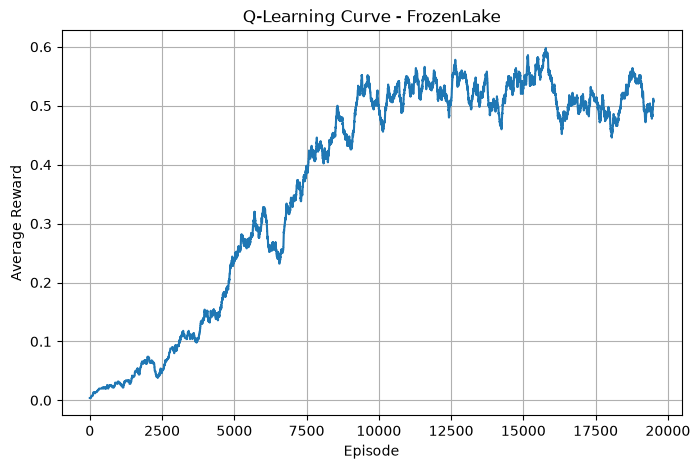

In [8]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()